In [41]:
#初始化  outputList ,outputList_temp,   wordsPosition   
#将wordList存放到outputList中，outputList的形状为单词图
#outputList中每个单词的起始坐标位置(row,column,direction)放在列表wordsPosition中,
#对于outputList中存放的每个单词，将它们的位置存放在列表wordsPosition中。位置有3个特征(行号，列号，方向)
#它们的行号和列号都初始化为-1，-1，负数表示无效，方向初始化为"h"，表示默认是水平方向存放
#字符内容为"-"表示可以填写，outputList每个单词的开头和结尾都是"-"。为"*"表示不可以填写
#假定输出的字母题目最多为M行N列
def initOW(M,N):    
    outputList = [['-'] * M for _ in range(N)]
    outputList_temp = [['-'] * M for _ in range(N)]    
    wordsPosition = []
    return outputList,outputList_temp,wordsPosition

#下列2行是最开始就必须执行的代码。因为下面3个是全局变量：outputList,outputList_temp,wordsPosition。
#M,N设定为常量，以后不要再修改
M = 20;N=20
outputList,outputList_temp,wordsPosition = initOW(M,N)#初始化3个列表,这是3个全局变量!!!!!!!!!!!!!
# outputList[0][8]='*'#修改第0个列表中第8个位置的字符内容为"*"
# wordsPosition[0][0]=-9
# wordsPosition[0][1]=-19
# wordsPosition[0][2]="h"

In [42]:
def printOutputList(outputList):    
    for i in range(len(outputList)):
        print(outputList[i])#输出列表的第i个成员的内容
       

In [43]:
#将outputList的全为'-'的行或列裁掉
def cropList1(outputList):
    for i in range(0,M,1):
        if outputList[i]!=['-'] * M : first_row = i;break
    for i in range(M-1,0,-1):
        if outputList[i]!=['-'] * M : last_row = i;break
    flag = 0#查找不全为'-'的第一列的列号
    for i in range(0,N,1):
        if flag == 1: break
        for j in range(first_row,last_row,1):
            if outputList[j][i]!='-': first_column = i;flag = 1;break
            
    flag = 0#查找不全为'-'的最后一列的列号
    for i in range(N-1,0,-1):
        if flag == 1: break
        for j in range(first_row,last_row,1):
            if outputList[j][i]!='-': last_column = i;flag = 1;break
    
    print(first_row,last_row,first_column,last_column)
    row_count = last_row - first_row + 1
    column_count = last_column - first_column + 1
    croppedList = [['-'] * row_count for _ in range(column_count)]
    c_i=0;c_j=0
    for i in range(first_row, last_row+1,1):
        c_j = 0
        for j in range(first_column,last_column+1):
            croppedList[c_i][c_j]=outputList[i][j]
            c_j = c_j+1
        c_i=c_i+1
    return croppedList  

In [44]:
#将outputList的全为'-'的行或列裁掉。先将outputList从列表list类型转化为数组类型np.array。这样方便裁剪
#裁剪完毕以后再转化为列表list类型，然后返回。
def cropList(outputList):
    import numpy as np    
    outputArray = np.array(outputList)
    for i in range(0,M,1):
        if sum(outputArray[i]!=['-'] * M) !=0 : first_row = i;break
    for i in range(M-1,0,-1):
        if sum(outputArray[i]!=['-'] * M) !=0 : last_row = i;break
    for i in range(0,N,1):
        if sum(outputArray[:,i]!=['-'] * N) !=0 : first_column = i;break
    for i in range(N-1,0,-1):
        if sum(outputArray[:,i]!=['-'] * N) !=0 : last_column = i;break
    print(first_row, last_row,first_column,last_column)
    return list(outputArray[first_row:last_row+1,first_column:last_column+1])                

In [45]:
#将outputList_temp中(行列号为(row,column)的字母以及它的上下左右的字母都改为*，表示以后不需要比较重复字母，不可以存放其它字母
def delCross(outputList_temp,row,column):
    outputList_temp[row][column]="*"
    outputList_temp[row-1][column]="*"
    outputList_temp[row+1][column]="*"
    outputList_temp[row][column-1]="*"
    outputList_temp[row][column+1]="*"

In [46]:
#输入列表wordList，返回乱序后的字符串wordListNew3
def shuffledList(wordList):
    import random
    wordListNew3=wordList[:]#复制列表，原列表保持不被改变
    #乱序：随意打乱列表wordListNew3中成员的顺序
    random.shuffle(wordListNew3)
    return wordListNew3

In [47]:
#输入列表wordList，返回字符串长短从小到大排序和从大到小排序的两个列表wordListNew1，wordListNew2
def sortedList(wordList):    
    import numpy as np
    #按照字符串长短从小到大排序，不是按照首字母的顺序，放入列表wordListNew1中。
    wordListNew1=[value for index, value in sorted(list(enumerate(wordList)), key=lambda x:len(x[1]))]
    #按照字符串长短从大到小排序，放入列表wordListNew2中。
    wordListNew2=wordListNew1[::-1]
    return wordListNew1,wordListNew2

In [48]:
#查找两个单词之间的重复字母，从第一个单词的第一个字母开始查重复
#返回第一个重复字母在第一个和第二单词中的位置(det_1,det_2)
def findDuplication(word1,word2):
    flag = 0; det_1 = -1;det_2 = -1;character=''
    for i in range(len(word1)):
        if flag == 1:
            break
        for j in range(len(word2)):
            if word1[i] == word2[j]:
                print("dup character:",word1[i],",dup position:",i,j)  #student可以打开输出提示
                character = word1[i]
                det_1 = i;det_2=j;
                flag = 1;break
    return character,det_1,det_2             
# findDuplication("skirt","shirt")
# findDuplication("dress","hat")
# findDuplication("shirt","dress")

In [49]:
#函数insertWord()的功能是：选择水平或垂直方向，复制单词到输出列表的指定位置
#sourceWord表示被复制的单词，将其复制到列表destOutputList中，
#复制的起始位置是(destRow,destColumn),direction表示复制的方向是水平还是垂直。"v"表示垂直，"h"表示水平
#如果目标位置有一个地方不是'-'，则返回-1，表示复制失败，否则返回1
#规则一：如果is_tempList为1，则是插入到outputList_temp中，那么需要!!!
#每插入一个单词，它的两端都不可以再存放字母，需要将其值从   '-'改为'*' 
def insertWord(destOutputList, destRow, destColumn, sourceWord, direction, is_tempList):
#     print(destOutputList[destX])
    is_success=1#默认能成功复制
    if direction == 'h':
        #查看水平的目标位置是否全为'-'，如果不是则不能成功复制，不复制，返回-1
        for i in range(len(sourceWord)):
            if(destOutputList[destRow][destColumn+i]!='-'):
                is_success = -1 
                return is_success
        #水平的目标位置全为'-'，开始水平复制
        print("insert word horizontally:",sourceWord)#student可以打开输出提示
        #规则一：每插入一个单词，它的两端都不可以再存放字母，需要将其值从   '-'改为'*' 
        if is_tempList:
            destOutputList[destRow][destColumn-1]='*'
        for i in range(len(sourceWord)):
            destOutputList[destRow][destColumn+i]=sourceWord[i]  
        if is_tempList:
            destOutputList[destRow][destColumn+len(sourceWord)]='*'
    else:    
        #查看垂直的目标位置是否全为'-'，如果不是则不能成功复制，不复制，返回-1
        for i in range(len(sourceWord)):
            if(destOutputList[destRow+i][destColumn]!='-'):
                is_success = -1 
                return is_success
        #垂直的目标位置全为'-'，开始垂直复制
        print("insert word vertically:",sourceWord)#student可以打开输出提示
        if is_tempList:
            destOutputList[destRow-1][destColumn]='*'
        for i in range(len(sourceWord)):
            destOutputList[destRow+i][destColumn]=sourceWord[i]
        if is_tempList:
            destOutputList[destRow+len(sourceWord)][destColumn]='*'
#     print("is_success",is_success)
    return is_success

# insertWord()使用方法举例：
# insertWord(outputList_temp,3,2,"dadada",'h')
# printOutputList(outputList_temp)

In [50]:
#从outputList_temp中取出已经插入的单词，然后查找待插入单词word2跟已插入单词列表中的word1是否有重复字母，从首个已插入单词开始查找
def combineOneWord(word2):
#(row,column,direction)为word1在outputList_temp中的行号、列号和方向，
#（dest_row，dest_column,dest_dir)为在outputList_temp中的行号、列号和方向，从此次插入word2
#（cross_row，cross_column)为在outputList_temp中的行号、列号，此处我word2与word1单词的交叉点
    is_success = -1#1表示成功，-1表示失败
    print("len(wordsPosition)",len(wordsPosition))
    for cur_i in range(len(wordsPosition)):
        word1 = []
        row = wordsPosition[cur_i][0]#待查重复字母的单词word1在outputList_temp中的行号
        column = wordsPosition[cur_i][1]#待查重复字母的单词word1在outputList_temp中的列号
        direction = wordsPosition[cur_i][2]#待查重复字母的单词word1在outputList_temp中的存放方向
        #根据word1的存放方向，从outputList中取出该单词，一个字母一个字母的存放到word1中。
        if direction == 'h':
            i = 0
            while outputList[row][column+i]!='-':
                word1.append(outputList_temp[row][column+i])
                i = i + 1
        else:
            i = 0
            while outputList[row+i][column]!='-':
                word1.append(outputList_temp[row+i][column])
                i = i + 1
        print("插入单词",word2,",outputList_temp中待比较的单词word1",word1,"的位置和方向是",row,column,direction)#student可以打开输出提示
        character,det_1,det_2 = findDuplication(word1,word2)#查找两个单词之间的重复字母character
        if det_1 ==-1: #wordsPosition中的当前cur_i单词跟word2无重复字母，取出下一个单词
            continue
        else:#wordsPosition中的当前cur_i单词跟word2有重复字母，开始插入
            #插入word2前，先将outputList和outputList_temp中交叉点的字母改为'-'，空出位置，否则无法插入完整的单词2。
            #如果插入不成功，则需要改回成原来的字母。
            if(direction=='h'):#如果word1是水平存放的，那么word2需要垂直插入，否则水平插入。
                dest_d = 'v'
                outputList[row][column+det_1]='-';outputList_temp[row][column+det_1]='-'
                dest_row = row-det_2;dest_column = column+det_1
                cross_row = row;cross_column = column+det_1 #交叉点的行号和列号，后面要以此为中心delCross（）
            else:
                dest_d = 'h'        
                outputList[row+det_1][column]='-';outputList_temp[row+det_1][column]='-'
                dest_row = row+det_1;dest_column = column-det_2
                cross_row = row+det_1;cross_column = column #交叉点的行号和列号，后面要以此为中心delCross（）
                
#             dest_row = row-det_2;dest_column = cur_column+det_1
            print("word1的位置为",row,column,"待插入单词word2即将插入的位置为",dest_row,dest_column)    #student可以打开输出提示 
            is_success = insertWord(outputList_temp,dest_row,dest_column,word2,dest_d,1)
            #outputList_temp能成功插入，然后才能插入到outputList，并进行其它相应的状态改变
            if is_success == 1:    
                insertWord(outputList,dest_row,dest_column,word2,dest_d,0)
                wordsPosition.append([dest_row,dest_column,dest_d])#插入成功，更新wordsPosition
                print("单词",word2,"成功插入，结果为") #student可以打开输出提示 
                delCross(outputList_temp,cross_row,cross_column)
#                 printOutputList(outputList)
#                 printOutputList(wordsPosition)
#                 printOutputList(outputList_temp)
                break#成功插入，则退出循环
            else:
                print("单词",word2,"虽然有重复字母，但无法插入，返回本单词插入失败，??在外面写代码将其移到wl的最后")#student可以打开输出提示
                if(direction=='h'):#如果word1是水平存放的，那么word2需要垂直插入，否则水平插入。
                    outputList_temp[row][column+det_1]=character;outputList[row][column+det_1]=character
                else:        
                    outputList_temp[row+det_1][column]=character;outputList[row+det_1][column]=character
    return is_success

In [51]:
#将单词列表wl的第0个单词放到outputList的正中间偏左2偏下2的位置
def insertFirstWord(wordList):
    init_row=int(M/2)-2  #当前单词存放的行号
    init_column=int(N/2)-2  #当前单词存放的列号
    init_d="h"  #当前单词存放的方向    
    insertWord(outputList,init_row,init_column,wordList[0],init_d,0) #将单词wordList[0]复制到列表outputList的指定位置
    insertWord(outputList_temp,init_row,init_column,wordList[0],init_d,1)#将单词wordList[0]复制到列表outputList_temp的指定位置
    wordsPosition.append([init_row,init_column,init_d])#用列表wordsPosition记录被复制单词的存放 在哪行哪列哪个方向
    print("outputList,wordsPosition,outputList_temp初始化，插入首个单词",wordList[0])    
#     printOutputList(outputList)
#     printOutputList(wordsPosition)
#     printOutputList(outputList_temp)

In [52]:
#开始使用以上定义的函数解决问题

In [53]:
 wordList0=[]
 inputWord=input("输入单词,输入q并回车表示结束")
 while inputWord!='q':
     wordList0.append(inputWord)
     print(inputWord)
     inputWord=input("输入单词,输入q并回车表示结束")

#wordList0=['tie','dress','shirt','skirt','hat','coat']
wordListInverted,wordList = sortedList(wordList0)

print(wordList,wordListInverted)


# wordList,wordListInverted= sortedList(wordList)
# wordListNew3 = shuffledList(wordList)

outputList,outputList_temp,wordsPosition = initOW(M,N)
flag = 0#flag为1表示插入所有单词成功了
for t in range(100):
    if flag == 1: break
    insertFirstWord(wordList)
    is_success = 1#插入首个单词成功
    i = 1#插入下一个单词
    while is_success == 1 and i < len(wordList0):        
        is_success=combineOneWord(wordList[i])
        i = i + 1 
    if is_success == -1: 
        print("插入失败，重试第",t+1,"次 ")
        wordList = shuffledList(wordList0)
        outputList,outputList_temp,wordsPosition = initOW(M,N)#初始化3个列表,这是3个全局变量        
    else:
        flag = 1;print("在第",t,"次乱序后全部单词插入成功")    
        printOutputList(outputList)
        printOutputList(wordsPosition)
        printOutputList(outputList_temp)

输入单词,输入q并回车表示结束dress
dress
输入单词,输入q并回车表示结束shirt
shirt
输入单词,输入q并回车表示结束skirt
skirt
输入单词,输入q并回车表示结束tie
tie
输入单词,输入q并回车表示结束sock
sock
输入单词,输入q并回车表示结束q
['skirt', 'shirt', 'dress', 'sock', 'tie'] ['tie', 'sock', 'dress', 'shirt', 'skirt']
insert word horizontally: skirt
insert word horizontally: skirt
outputList,wordsPosition,outputList_temp初始化，插入首个单词 skirt
len(wordsPosition) 1
插入单词 shirt ,outputList_temp中待比较的单词word1 ['s', 'k', 'i', 'r', 't'] 的位置和方向是 8 8 h
dup character: s ,dup position: 0 0
word1的位置为 8 8 待插入单词word2即将插入的位置为 8 8
insert word vertically: shirt
insert word vertically: shirt
单词 shirt 成功插入，结果为
len(wordsPosition) 2
插入单词 dress ,outputList_temp中待比较的单词word1 ['*', '*', 'i', 'r', 't'] 的位置和方向是 8 8 h
dup character: r ,dup position: 3 1
word1的位置为 8 8 待插入单词word2即将插入的位置为 7 11
insert word vertically: dress
insert word vertically: dress
单词 dress 成功插入，结果为
len(wordsPosition) 3
插入单词 sock ,outputList_temp中待比较的单词word1 ['*', '*', '*', '*', '*'] 的位置和方向是 8 8 h
插入单词 sock ,outputList_temp中待比较的单词word1 ['*

In [54]:
o1 = cropList(outputList)
printOutputList(o1)
row_count=len(o1);column_count=len(o1[0])
print("输出单词题的行列数目为：",row_count,column_count)

7 12 7 14
['-' '-' '-' '-' 'd' '-' '-' '-']
['-' 's' 'k' 'i' 'r' 't' '-' '-']
['-' 'h' '-' '-' 'e' '-' '-' '-']
['t' 'i' 'e' '-' 's' 'o' 'c' 'k']
['-' 'r' '-' '-' 's' '-' '-' '-']
['-' 't' '-' '-' '-' '-' '-' '-']
输出单词题的行列数目为： 6 8


# 将以上代码做成模块，后期完成

In [55]:
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
def plotImg(img, title=""):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)#, plt.axis("off")
    else:
        plt.imshow(img, cmap='gray')#, plt.axis("off")
    plt.title(title)
    plt.show()
#所拍摄的照片中的数字不要离边框太近，否则不容易提取出边缘的轮廓

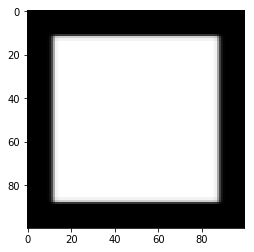

In [56]:
#输出的图片的边框边长为B个像素，设定B为100
B= 100
blacksidePic = cv2.imread('blackside.bmp')#,cv2.IMREAD_GRAYSCALE)
# print(blacksidePic[0:7,:],type(blacksidePic))
plotImg(blacksidePic)

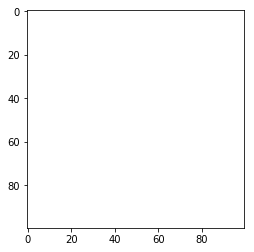

In [57]:
#每个方格的长宽
purewhitePic = cv2.imread('purewhite.bmp')#,cv2.IMREAD_GRAYSCALE)
# print(temp[0:7,:],type(temp))
plotImg(purewhitePic)
# print(purewhitePic[0:7,:,0],type(purewhitePic))

In [58]:
# purewhitePic.copy()

(600, 800, 3)


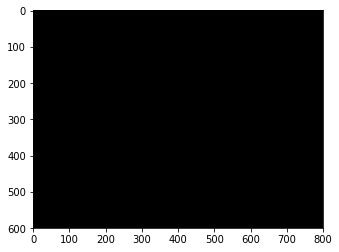

In [59]:
pic=np.zeros((B*row_count,B*column_count,3),dtype=np.uint8)

print(pic.shape)
# print(pic[:,:,0])
plotImg(pic)

In [60]:

for i in range(row_count):
    for j in range(column_count):
        if o1[i][j]=='-':
#             print("-","i:",i,"j:",j,(i)*B,(i+1)*B, (j)*B,(j+1)*B)
            pic[(i)*B:(i+1)*B, (j)*B:(j+1)*B, :] = purewhitePic.copy()
        else:     
#             print(o1[i][j],"i:",i,"j:",j,(i)*B,(i+1)*B, (j)*B,(j+1)*B) 
            pic[(i)*B:(i+1)*B, (j)*B:(j+1)*B,  :] = blacksidePic.copy()

# plotImg(pic)

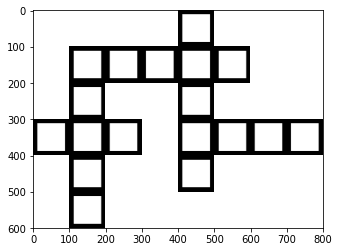

True

In [61]:
plotImg(pic)
cv2.imwrite("outputPic.jpg",pic)